# EEG result figures

Locked-test comparisons of the selected baseline runs and NAS-selected architectures.

In [19]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

dataset_labels = {'bnci2014_001': 'BNCI', 'lee2019_mi': 'Lee', 'physionet_mi': 'PhysioNet'}
model_labels = {
    'compact_eegnet': 'Compact', 'deep_separable': 'Deep', 'wide_eegnet': 'Wide',
    'shallow_temporal': 'Shallow', 'dilated_temporal': 'Dilated',
}
model_order = list(model_labels)
source_colors = {'bnci2014_001': '#2563eb', 'lee2019_mi': '#059669', 'physionet_mi': '#dc2626'}
DATA_ROOT = Path('../data') if Path('../data').exists() else Path('data')

BASELINE_RUNS = [
    'fixed',
    'scaled',
]
BASELINE_RUN_IDS = {'fixed': 'baseline-seed{seed}', 'scaled': 'scaled-seed{seed}'}
unknown_baseline_runs = set(BASELINE_RUNS) - set(BASELINE_RUN_IDS)
if not BASELINE_RUNS or unknown_baseline_runs:
    raise ValueError(f'Select at least one valid baseline run; unknown: {sorted(unknown_baseline_runs)}')

def selected_baseline_files(stage, filename):
    files = [
        DATA_ROOT / f'seed-{seed}' / 'benchmarking' / stage
        / BASELINE_RUN_IDS[run].format(seed=seed) / 'epochs-40' / filename
        for run in BASELINE_RUNS
        for seed in range(3)
    ]
    missing = [path for path in files if not path.exists()]
    if missing:
        raise FileNotFoundError(f'Missing selected baseline files: {missing}')
    return files

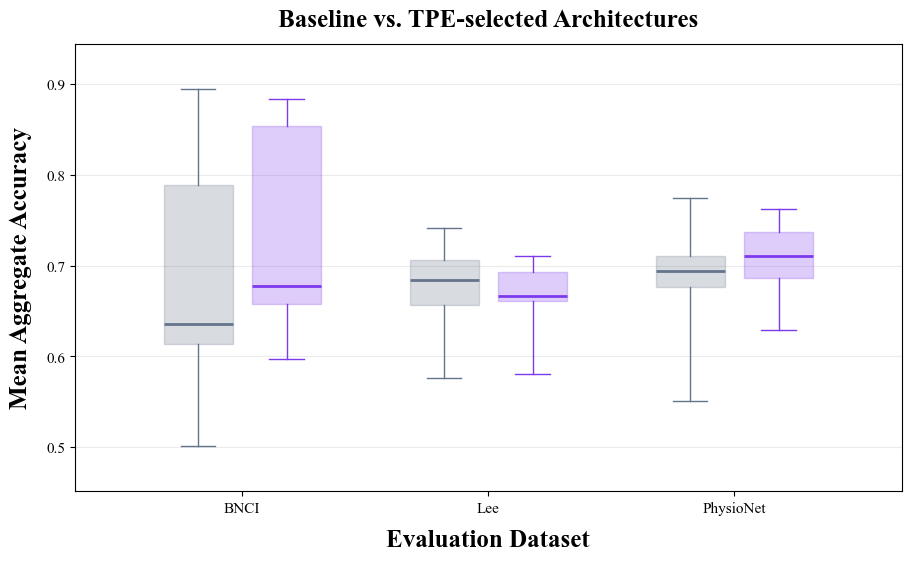

In [32]:
# Accuracy-only comparison (raw 0–1 values; no normalization)
METRICS = [
    # Overall predictive quality — choose one
    'balanced_accuracy',
    # 'accuracy',
    # 'macro_f1',

    # Class robustness — choose one or omit this section
    'worst_class_recall',
    # 'left_recall', # among all true left trials, how many were predicted as left?
    # 'right_recall', # among all true right trials, how many were predicted as right?
    # 'left_precision',
    # 'right_precision',

    # Subject robustness — choose one or omit this section
    # 'subject_min_accuracy',
    'subject_median_accuracy',
]

# for easy adjustment instead of poking around the code forever
SHOW_COMPONENT_POINTS = False
SHOW_COMPOSITE_POINTS = False
DISPLAY_RAW_METRICS_FIGURE = False
DISPLAY_RAW_COMPOSITE_FIGURE = True
Y_AXIS_MARGIN = 0.05
COMPONENT_Y_LIMITS = None  # Example: (0.45, 1.0)
COMPOSITE_Y_LIMITS = None
COMPONENT_FIGURE_SIZE = (12, 5.5)
COMPOSITE_FIGURE_SIZE = (9, 5.5)
COMPONENT_TITLE = 'Selected raw accuracy metrics'
COMPOSITE_TITLE = 'Baseline vs. TPE-selected Architectures'
COMPOSITE_X_LABEL = 'Evaluation Dataset'
TITLE_SIZE = 18
TITLE_Y = 1.02
X_AXIS_LABEL_SIZE = 18
Y_AXIS_LABEL_SIZE = 18
X_AXIS_LABEL_PAD = 10
Y_AXIS_LABEL_PAD = 10
TICK_LABEL_SIZE = 11
LEGEND_SIZE = 11
FONT_FAMILY = 'serif'
SERIF_FONTS = ['Computer Modern Roman', 'Latin Modern Roman', 'Times New Roman', 'Times']
BASELINE_COLOR = '#64748b'
NAS_COLOR = '#7c3aed'
BASELINE_BOX_WIDTH = 0.28
NAS_BOX_WIDTH = 0.28
BASELINE_POSITION_OFFSET = -0.18
NAS_POSITION_OFFSET = 0.18

plt.rcParams.update({
    'font.family': FONT_FAMILY,
    'font.serif': SERIF_FONTS,
    'mathtext.fontset': 'cm',
})

accuracy_metric_labels = {
    'accuracy': 'Accuracy',
    'balanced_accuracy': 'Balanced accuracy',
    'macro_f1': 'Macro F1',
    'worst_class_recall': 'Worst-class recall',
    'left_recall': 'Left recall',
    'right_recall': 'Right recall',
    'left_precision': 'Left precision',
    'right_precision': 'Right precision',
    'subject_median_accuracy': 'Median subject accuracy',
    'subject_min_accuracy': 'Minimum subject accuracy',
}
unknown_accuracy_metrics = set(METRICS) - set(accuracy_metric_labels)
if not METRICS or unknown_accuracy_metrics:
    raise ValueError(f'Select at least one valid accuracy metric; unknown: {sorted(unknown_accuracy_metrics)}')

baseline_test_files = selected_baseline_files('final-testing', 'test_results.jsonl')
nas_test_files = sorted(DATA_ROOT.glob('seed-*/eeg-parzen/final-testing/*/epochs-40/test_results.jsonl'))
if len(nas_test_files) != 3:
    raise RuntimeError('Expected three NAS final-test files')
comparison_rows = []
for family, paths in [('Baseline', baseline_test_files), ('NAS', nas_test_files)]:
    for path in paths:
        for entry in (json.loads(line) for line in path.open() if line.strip()):
            test = entry['test']
            subject_scores = pd.Series(test['per_subject_accuracy'].values(), dtype=float)
            comparison_rows.append({
                'family': family,
                'seed': entry['seed'],
                'dataset': entry.get('dataset', entry.get('target_dataset')),
                'candidate': entry.get('baseline', entry.get('source_dataset')),
                **{metric: test[metric] for metric in [
                    'accuracy', 'balanced_accuracy', 'macro_f1',
                    'left_recall', 'right_recall', 'left_precision', 'right_precision',
                ]},
                'worst_class_recall': min(test['left_recall'], test['right_recall']),
                'subject_median_accuracy': subject_scores.median(),
                'subject_min_accuracy': subject_scores.min(),
            })
comparison = pd.DataFrame(comparison_rows)

accuracy_long = comparison.melt(
    id_vars=['family', 'seed', 'dataset', 'candidate'],
    value_vars=METRICS,
    var_name='metric', value_name='score',
)
accuracy_composite = (
    accuracy_long.groupby(['family', 'seed', 'dataset', 'candidate'], as_index=False)['score'].mean()
)
component_ylim = COMPONENT_Y_LIMITS or (accuracy_long['score'].min() - Y_AXIS_MARGIN, accuracy_long['score'].max() + Y_AXIS_MARGIN)
composite_ylim = COMPOSITE_Y_LIMITS or (accuracy_composite['score'].min() - Y_AXIS_MARGIN, accuracy_composite['score'].max() + Y_AXIS_MARGIN)
component_fig, component_axis = plt.subplots(
    figsize=COMPONENT_FIGURE_SIZE, constrained_layout=True,
)
colors = {'Baseline': BASELINE_COLOR, 'NAS': NAS_COLOR}
for center, metric in enumerate(METRICS):
    for family, position in [
        ('Baseline', center + BASELINE_POSITION_OFFSET),
        ('NAS', center + NAS_POSITION_OFFSET),
    ]:
        values = accuracy_long.loc[(accuracy_long['metric'] == metric) & (accuracy_long['family'] == family), 'score']
        box_width = NAS_BOX_WIDTH if family == 'NAS' else BASELINE_BOX_WIDTH
        component_axis.boxplot(
            values, positions=[position], widths=box_width, patch_artist=True, whis=(0, 100),
            boxprops={'facecolor': colors[family], 'edgecolor': colors[family], 'alpha': 0.25},
            medianprops={'color': colors[family], 'linewidth': 2},
            whiskerprops={'color': colors[family]}, capprops={'color': colors[family]},
        )
        if SHOW_COMPONENT_POINTS:
            offsets = [(index - (len(values) - 1) / 2) * 0.012 for index in range(len(values))]
            component_axis.scatter([position + offset for offset in offsets], values, color=colors[family], s=24, alpha=0.8, zorder=3)
component_axis.set(
    xticks=list(range(len(METRICS))),
    xticklabels=[accuracy_metric_labels[metric] for metric in METRICS],
    ylim=component_ylim,
)
component_axis.set_title(COMPONENT_TITLE, fontsize=TITLE_SIZE, y=TITLE_Y)
component_axis.set_ylabel('Score', fontsize=Y_AXIS_LABEL_SIZE, labelpad=Y_AXIS_LABEL_PAD)
component_axis.tick_params(axis='x', rotation=30, labelsize=TICK_LABEL_SIZE)
component_axis.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
component_axis.grid(axis='y', alpha=0.25)
component_axis.scatter([], [], color=colors['Baseline'], label='Baseline')
component_axis.scatter([], [], color=colors['NAS'], label='NAS')
component_axis.legend(fontsize=LEGEND_SIZE)
if DISPLAY_RAW_METRICS_FIGURE:
    plt.show()
else:
    plt.close(component_fig)

composite_fig, composite_axis = plt.subplots(figsize=COMPOSITE_FIGURE_SIZE, constrained_layout=True)
for center, dataset in enumerate(dataset_labels):
    for family, position in [
        ('Baseline', center + BASELINE_POSITION_OFFSET),
        ('NAS', center + NAS_POSITION_OFFSET),
    ]:
        values = accuracy_composite.loc[(accuracy_composite['dataset'] == dataset) & (accuracy_composite['family'] == family), 'score']
        box_width = NAS_BOX_WIDTH if family == 'NAS' else BASELINE_BOX_WIDTH
        composite_axis.boxplot(
            values, positions=[position], widths=box_width, patch_artist=True, whis=(0, 100),
            boxprops={'facecolor': colors[family], 'edgecolor': colors[family], 'alpha': 0.25},
            medianprops={'color': colors[family], 'linewidth': 2},
            whiskerprops={'color': colors[family]}, capprops={'color': colors[family]},
        )
        if SHOW_COMPOSITE_POINTS:
            offsets = [(index - (len(values) - 1) / 2) * 0.012 for index in range(len(values))]
            composite_axis.scatter([position + offset for offset in offsets], values, color=colors[family], s=24, alpha=0.8, zorder=3)
composite_axis.set(
    xticks=list(range(len(dataset_labels))),
    xticklabels=[dataset_labels[dataset] for dataset in dataset_labels], ylim=composite_ylim,
)
composite_axis.set_title(f'{COMPOSITE_TITLE}', fontsize=TITLE_SIZE, fontweight='bold', y=TITLE_Y)
composite_axis.set_xlabel(COMPOSITE_X_LABEL, fontsize=X_AXIS_LABEL_SIZE, fontweight='bold', labelpad=X_AXIS_LABEL_PAD)
composite_axis.set_ylabel('Mean Aggregate Accuracy', fontsize=Y_AXIS_LABEL_SIZE, fontweight='bold', labelpad=Y_AXIS_LABEL_PAD)
composite_axis.tick_params(axis='both', labelsize=TICK_LABEL_SIZE)
composite_axis.grid(axis='y', alpha=0.25)
if DISPLAY_RAW_COMPOSITE_FIGURE:
    plt.show()
else:
    plt.close(composite_fig)

In [21]:
run = False

if run:
    COMPARISON_METRICS = [
        # Predictive quality — choose one
        # 'balanced_accuracy',
        'accuracy',
        # 'macro_f1',
        # 'loss',

        # Subject robustness — choose one
        'subject_min_accuracy',
        # 'subject_median_accuracy',
        # 'subject_accuracy_sd',

        # Class robustness — choose one
        'worst_class_recall',
        # 'left_recall',
        # 'right_recall',
        # 'left_precision',
        # 'right_precision',

        # Inference efficiency — choose one (N/A)
        # 'inference_ms_per_trial',
        # 'inference_trials_per_second',

        # Model efficiency — choose one (N/A)
        # 'parameter_count',
        # 'serialized_state_bytes',

        # Training efficiency — optional; concurrent GPU load affects this
        # 'training_seconds',
    ]
    SHOW_COMPOSITE_POINTS = False

    metric_specs = {
        'accuracy': ('Accuracy', True),
        'balanced_accuracy': ('Balanced accuracy', True),
        'macro_f1': ('Macro F1', True),
        'worst_class_recall': ('Worst-class recall', True),
        'left_recall': ('Left recall', True),
        'right_recall': ('Right recall', True),
        'left_precision': ('Left precision', True),
        'right_precision': ('Right precision', True),
        'subject_median_accuracy': ('Median subject accuracy', True),
        'subject_min_accuracy': ('Minimum subject accuracy', True),
        'subject_accuracy_sd': ('Subject accuracy SD', False),
        'loss': ('Cross-entropy loss', False),
        'inference_ms_per_trial': ('Inference time', False),
        'inference_trials_per_second': ('Inference throughput', True),
        'parameter_count': ('Parameters', False),
        'serialized_state_bytes': ('Model size', False),
        'training_seconds': ('Training time', False),
    }
    unknown_metrics = set(COMPARISON_METRICS) - set(metric_specs)
    if not COMPARISON_METRICS or unknown_metrics:
        raise ValueError(f'Select at least one valid metric; unknown: {sorted(unknown_metrics)}')

    baseline_training_files = selected_baseline_files('final-training', 'training_results.jsonl')
    nas_training_files = sorted(DATA_ROOT.glob('seed-*/eeg-parzen/final-training/*/epochs-40/training_results.jsonl'))
    baseline_training = {
        (entry['seed'], entry['dataset'], entry['baseline']): entry
        for path in baseline_training_files
        for entry in (json.loads(line) for line in path.open() if line.strip())
    }
    nas_training = {
        (entry['seed'], entry['target_dataset'], entry['source_dataset']): entry
        for path in nas_training_files
        for entry in (json.loads(line) for line in path.open() if line.strip())
    }
    comparison_rows = []
    for family, paths in [('Baseline', baseline_test_files), ('NAS', nas_test_files)]:
        for path in paths:
            for entry in (json.loads(line) for line in path.open() if line.strip()):
                test = entry['test']
                dataset = entry.get('dataset', entry.get('target_dataset'))
                candidate = entry.get('baseline', entry.get('source_dataset'))
                training = (baseline_training if family == 'Baseline' else nas_training)[(entry['seed'], dataset, candidate)]
                subject_scores = pd.Series(test['per_subject_accuracy'].values(), dtype=float)
                comparison_rows.append({
                    'family': family, 'seed': entry['seed'], 'dataset': dataset, 'candidate': candidate,
                    **{name: test[name] for name in [
                        'loss', 'accuracy', 'balanced_accuracy', 'macro_f1',
                        'left_recall', 'right_recall', 'left_precision', 'right_precision',
                        'inference_ms_per_trial', 'inference_trials_per_second', 'serialized_state_bytes',
                    ]},
                    'worst_class_recall': min(test['left_recall'], test['right_recall']),
                    'subject_median_accuracy': subject_scores.median(),
                    'subject_min_accuracy': subject_scores.min(),
                    'subject_accuracy_sd': subject_scores.std(),
                    'parameter_count': training['parameter_count'],
                    'training_seconds': training['training_seconds'],
                })
    comparison = pd.DataFrame(comparison_rows)
    normalized_rows = []
    for (seed, dataset), group in comparison.groupby(['seed', 'dataset']):
        for metric in COMPARISON_METRICS:
            minimum, maximum = group[metric].min(), group[metric].max()
            span = maximum - minimum
            higher_is_better = metric_specs[metric][1]
            for _, row in group.iterrows():
                score = 0.5 if span == 0 else (row[metric] - minimum) / span
                normalized_rows.append({
                    'family': row['family'], 'seed': seed, 'dataset': dataset,
                    'candidate': row['candidate'], 'metric': metric,
                    'score': score if higher_is_better else 1 - score,
                })
    normalized_components = pd.DataFrame(normalized_rows)
    composite = (
        normalized_components.groupby(['family', 'seed', 'dataset', 'candidate'], as_index=False)['score'].mean()
    )
    fig, axes = plt.subplots(1, 2, figsize=(max(12, 2.2 * len(COMPARISON_METRICS) + 6), 5.5), constrained_layout=True)
    component_axis, composite_axis = axes
    colors = {'Baseline': '#64748b', 'NAS': '#7c3aed'}
    for center, metric in enumerate(COMPARISON_METRICS):
        for family, position in [('Baseline', center - 0.18), ('NAS', center + 0.18)]:
            values = normalized_components.loc[(normalized_components['metric'] == metric) & (normalized_components['family'] == family), 'score']
            component_axis.boxplot(
                values, positions=[position], widths=0.28, patch_artist=True, whis=(0, 100),
                boxprops={'facecolor': colors[family], 'edgecolor': colors[family], 'alpha': 0.25},
                medianprops={'color': colors[family], 'linewidth': 2},
                whiskerprops={'color': colors[family]}, capprops={'color': colors[family]},
            )
    component_axis.set(
        title='Selected normalized components', ylabel='Normalized score (higher is better)',
        xticks=list(range(len(COMPARISON_METRICS))),
        xticklabels=[metric_specs[metric][0] for metric in COMPARISON_METRICS], ylim=(-0.05, 1.05),
    )
    component_axis.tick_params(axis='x', rotation=30)
    component_axis.grid(axis='y', alpha=0.25)
    component_axis.scatter([], [], color=colors['Baseline'], label='Baseline')
    component_axis.scatter([], [], color=colors['NAS'], label='NAS')
    # component_axis.legend()
    for center, dataset in enumerate(dataset_labels):
        for family, position in [('Baseline', center - 0.18), ('NAS', center + 0.18)]:
            values = composite.loc[(composite['dataset'] == dataset) & (composite['family'] == family), 'score']
            composite_axis.boxplot(
                values, positions=[position], widths=0.28, patch_artist=True, whis=(0, 100),
                boxprops={'facecolor': colors[family], 'edgecolor': colors[family], 'alpha': 0.25},
                medianprops={'color': colors[family], 'linewidth': 2},
                whiskerprops={'color': colors[family]}, capprops={'color': colors[family]},
            )
            if SHOW_COMPOSITE_POINTS:
                offsets = [(index - (len(values) - 1) / 2) * 0.012 for index in range(len(values))]
                composite_axis.scatter([position + offset for offset in offsets], values, color=colors[family], s=24, alpha=0.8, zorder=3)
    composite_axis.set(
        title=f'Equal-weight composite ({len(COMPARISON_METRICS)} metrics)',
        ylabel='Composite normalized score', xticks=list(range(len(dataset_labels))),
        xticklabels=[dataset_labels[dataset] for dataset in dataset_labels], ylim=(-0.05, 1.05),
    )
    composite_axis.grid(axis='y', alpha=0.25)
    plt.show()

    raw_fig, raw_axes = plt.subplots(
        1, len(COMPARISON_METRICS),
        figsize=(max(10, 2.5 * len(COMPARISON_METRICS)), 4.5),
        squeeze=False, constrained_layout=True,
    )
    for raw_axis, metric in zip(raw_axes[0], COMPARISON_METRICS, strict=True):
        medians = {}
        for position, family in enumerate(['Baseline', 'NAS']):
            values = comparison.loc[comparison['family'] == family, metric]
            color = colors[family]
            raw_axis.boxplot(
                values, positions=[position], widths=0.5, patch_artist=True, whis=(0, 100),
                boxprops={'facecolor': color, 'edgecolor': color, 'alpha': 0.25},
                medianprops={'color': color, 'linewidth': 2},
                whiskerprops={'color': color}, capprops={'color': color},
            )
            medians[family] = values.median()
        raw_axis.set(xticks=[0, 1], xticklabels=['Baseline', 'NAS'], yticks=[])
        raw_axis.set_title(
            f"{metric_specs[metric][0]}\nB {medians['Baseline']:.3g}  |  N {medians['NAS']:.3g}",
            fontsize=10,
        )
        raw_axis.grid(axis='y', alpha=0.2)
    raw_fig.suptitle('Raw metric distributions (independent native-unit scales)', fontsize=14)
    plt.show()